In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [163]:
df=pd.read_csv(r"../data/student_dropout_dataset.csv")
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [164]:
df.shape

(10000, 19)

In [165]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [167]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [168]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [169]:
df.isnull().sum().sum()

np.int64(2011)

In [170]:
fill_columns=["Family_Income","Study_Hours_per_Day","Stress_Index"]

In [171]:
for col in fill_columns:
    df[col]=df[col].fillna(df[col].median())

In [172]:
df["Parental_Education"] = df["Parental_Education"].fillna(df["Parental_Education"].mode()[0])

In [173]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [174]:
df["Dropout"].value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

- The dataset is moderately imbalanced with ~76% non-dropout and ~24% dropout cases. Accuracy alone will not be a reliable metric, so evaluation will include precision, recall, F1-score, and ROC-AUC.

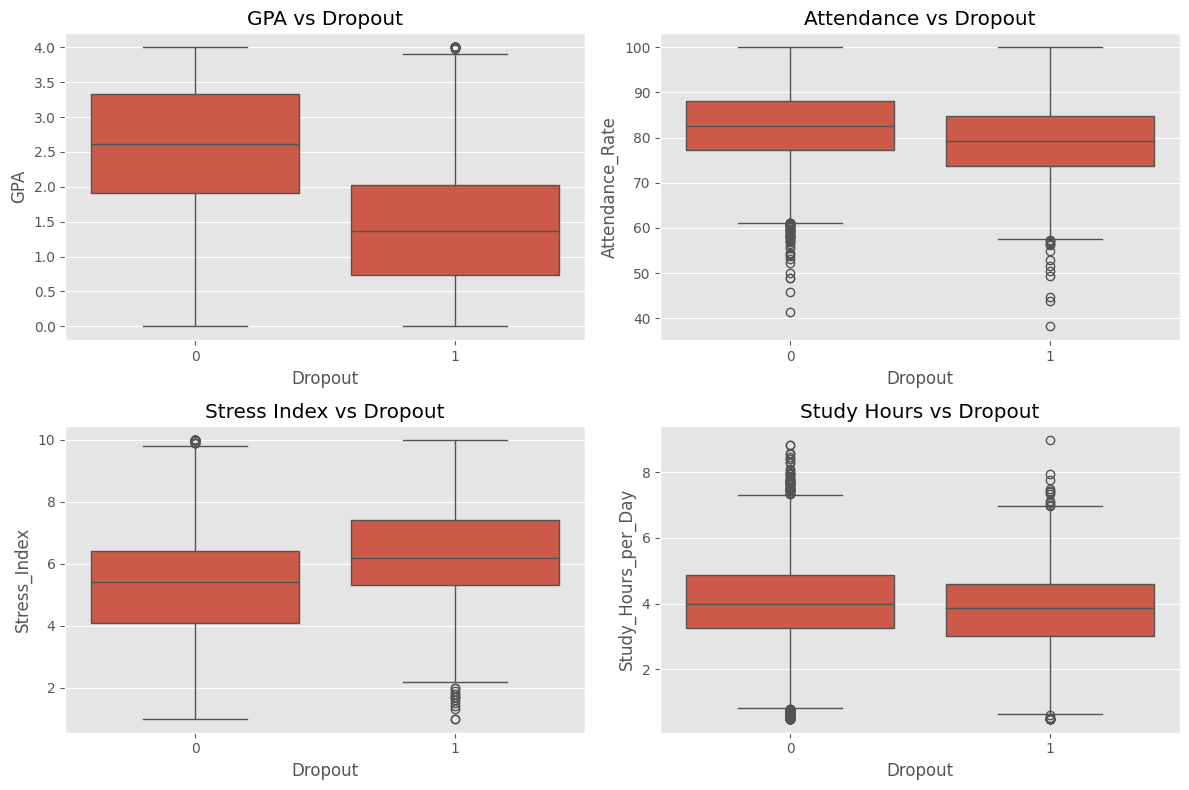

In [175]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x="Dropout", y="GPA", data=df, ax=axes[0,0])
axes[0,0].set_title("GPA vs Dropout")

sns.boxplot(x="Dropout", y="Attendance_Rate", data=df, ax=axes[0,1])
axes[0,1].set_title("Attendance vs Dropout")

sns.boxplot(x="Dropout", y="Stress_Index", data=df, ax=axes[1,0])
axes[1,0].set_title("Stress Index vs Dropout")

sns.boxplot(x="Dropout", y="Study_Hours_per_Day", data=df, ax=axes[1,1])
axes[1,1].set_title("Study Hours vs Dropout")

plt.tight_layout()
plt.show()

- GPA shows a strong separation between dropout and non-dropout students.
- Attendance and Stress Index show moderate differences with noticeable overlap.
- Study Hours shows minimal difference between the two groups.

GPA is the most important feature, while Attendance and Stress contribute moderately. Study Hours alone has weak predictive power.

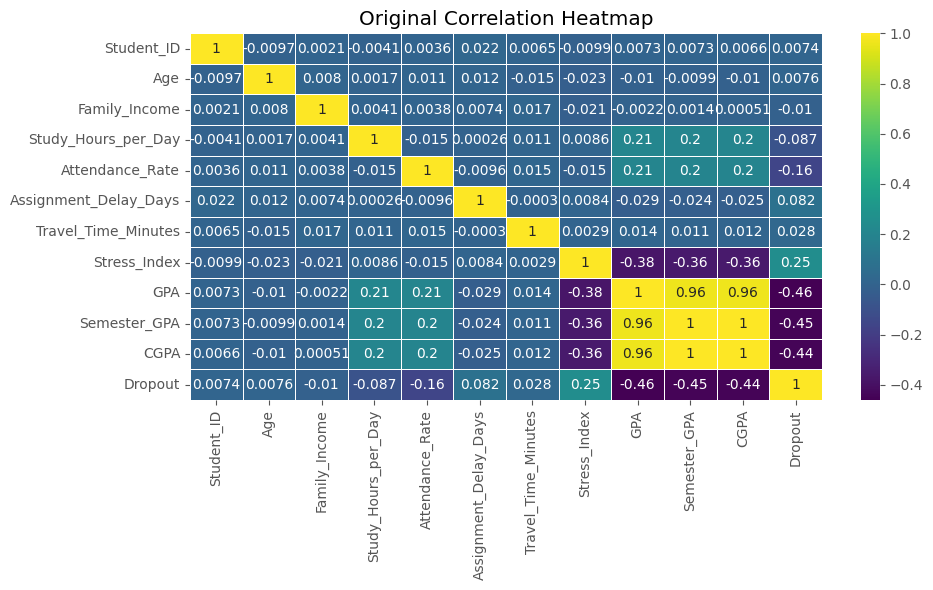

In [176]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis",linewidths=0.5)
plt.title("Original Correlation Heatmap")
plt.tight_layout()
plt.show()

- High correlation was observed between GPA, Semester_GPA, and CGPA (correlation > 0.9).


In [177]:
df=df.drop(columns=["Semester_GPA","CGPA","Student_ID"])

In [178]:
df.columns

Index(['Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester', 'Department', 'Parental_Education', 'Dropout'],
      dtype='object')

- Correlation analysis revealed a very high correlation (> 0.9) between GPA, Semester_GPA, and CGPA, indicating multicollinearity. Since these features carry similar information, retaining all of them can negatively impact model stability and interpretability.
- To address this, only GPA was retained as it reflects current academic performance, while Semester_GPA and CGPA were removed. Additionally, Student_ID was dropped as it does not contribute to prediction.

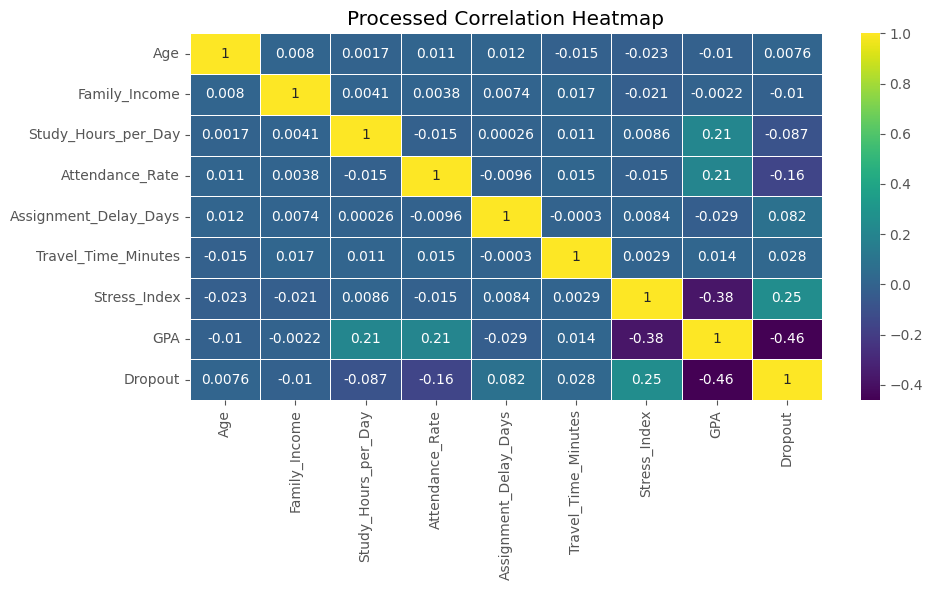

In [179]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis",linewidths=0.5)
plt.title("Processed Correlation Heatmap")
plt.tight_layout()
plt.show()

In [191]:
from sklearn.model_selection import train_test_split
X=df.drop("Dropout",axis=1)
y=df["Dropout"]

X_train,X_test,y_train,y_test=train_test_split(X , y , test_size=0.2,random_state=42,stratify=y)

In [192]:
y_train.value_counts(normalize=True)

Dropout
0    0.764625
1    0.235375
Name: proportion, dtype: float64

In [193]:
y_test.value_counts(normalize=True)

Dropout
0    0.7645
1    0.2355
Name: proportion, dtype: float64

- The dataset was divided into training and testing sets using an 80:20 ratio to evaluate the model's performance on unseen data.

- The dataset is moderately imbalanced (~76% non-dropout and ~24% dropout). To ensure both training and testing sets maintain the same class distribution, stratified sampling was applied. This helps in achieving a fair and reliable evaluation.

- The train-test split is performed after data cleaning and feature selection but before feature engineering, encoding, and scaling. This is done to prevent data leakage, ensuring that transformations applied later do not use information from the test set.


## FEATURE ENGINEERING

### 1️⃣.Academic Risk

In [195]:
X_train["Academic_Risk"]=X_train["GPA"]*X_train["Attendance_Rate"]
X_test["Academic_Risk"]=X_test["GPA"]*X_test["Attendance_Rate"]

In [196]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Academic_Risk
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,25.235
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,111.562
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,92.796
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,186.192
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,28.424


- This feature combines GPA and attendance to capture overall academic performance. Students with low GPA and low attendance are more likely to drop out, and this interaction helps the model identify high-risk cases more effectively.
- **Impact** : Improves the model’s ability to detect students at academic risk by combining two important signals.


### 2️⃣.Effort_Ratio

In [197]:
X_train["Effort_Ratio"]=X_train["Study_Hours_per_Day"]/(X_train["GPA"]+1)
X_test["Effort_Ratio"]=X_test["Study_Hours_per_Day"]/(X_test["GPA"]+1)

In [198]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Academic_Risk,Effort_Ratio
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,25.235,3.503704
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,111.562,1.565611
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,92.796,0.672414
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,186.192,1.155063
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,28.424,3.152778


- This feature represents the relationship between study effort and academic performance. It helps identify students who study more but still have low GPA, indicating inefficiency or learning difficulties. A constant (+1) is added to GPA to avoid division by zero and maintain stability.
- **Impact**: Helps detect mismatch between effort and performance, which can signal potential dropout risk.

### 3️⃣Stress_Impact

In [199]:
X_train["Stress_Impact"]=X_train["Stress_Index"]*(100-X_train["Attendance_Rate"])
X_test["Stress_Impact"]=X_test["Stress_Index"]*(100-X_test["Attendance_Rate"])

In [200]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Academic_Risk,Effort_Ratio,Stress_Impact
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,25.235,3.503704,270.63
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,111.562,1.565611,68.64
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,92.796,0.672414,139.59
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,186.192,1.155063,91.08
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,28.424,3.152778,223.02


- This feature combines stress level and attendance to capture behavioral risk. High stress along with low attendance indicates a higher likelihood of dropout, and this interaction makes the pattern more explicit.
- **Impact**: Enhances the model’s ability to identify students under high stress who are disengaging from classes.

In [202]:
X_train.shape

(8000, 18)

In [203]:
X_train.isnull().sum()

Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester                 0
Department               0
Parental_Education       0
Academic_Risk            0
Effort_Ratio             0
Stress_Impact            0
dtype: int64

### Correlation Analysis After Feature Engineering

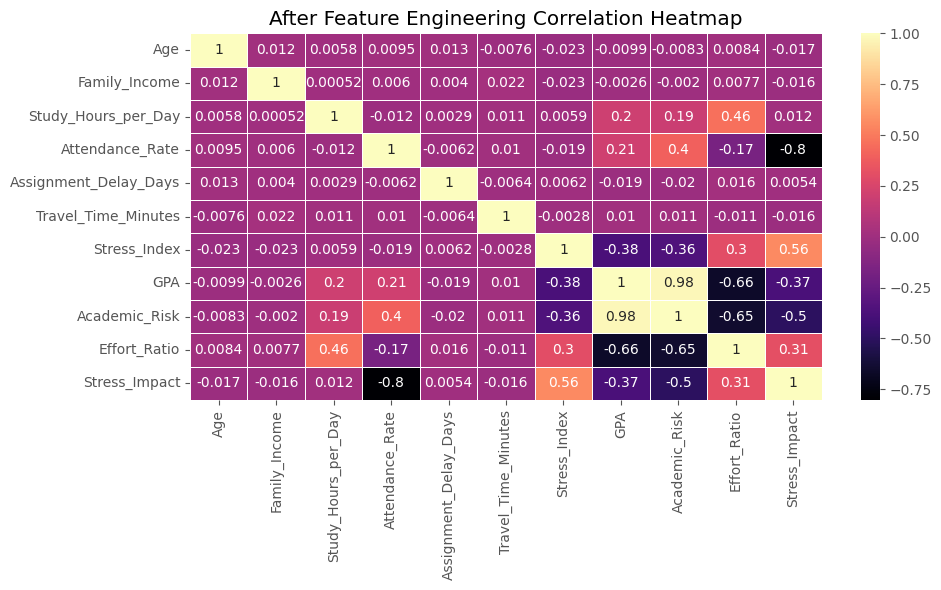

In [216]:
corr_matrix = X_train.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="magma",linewidths=0.5)
plt.title("After Feature Engineering Correlation Heatmap")
plt.tight_layout()
plt.show()

- The correlation heatmap was analyzed after creating new features to check for redundancy and multicollinearity. It was observed that Academic_Risk is highly correlated with GPA (~0.98), indicating that it does not provide additional information.
- Therefore, Academic_Risk was removed to avoid multicollinearity. Other engineered features like Effort_Ratio and Stress_Impact were retained as they show moderate correlation and capture different aspects of student behavior.

In [217]:
X_train=X_train.drop("Academic_Risk",axis=1)
X_test=X_test.drop("Academic_Risk",axis=1)

In [219]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Effort_Ratio,Stress_Impact
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,3.503704,270.63
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,1.565611,68.64
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,0.672414,139.59
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,1.155063,91.08
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,3.152778,223.02


- Academic_Risk was removed because it showed a very high correlation with GPA (~0.98), indicating that it does not add new information and may cause multicollinearity.
- Effort_Ratio was retained as it captures the relationship between study effort and performance, providing additional insight beyond individual features.
- Stress_Impact was retained as it represents the interaction between stress and attendance, helping the model identify students at behavioral risk.
hese decisions ensure that only meaningful and non-redundant features are used for model training.


## Categorical Feature Encoding

In [220]:
X_train=pd.get_dummies(X_train,drop_first=True)
X_test=pd.get_dummies(X_test,drop_first=True)

In [229]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [232]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [233]:
X_train.columns

Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Effort_Ratio', 'Stress_Impact', 'Gender_Male', 'Internet_Access_Yes',
       'Part_Time_Job_Yes', 'Scholarship_Yes', 'Semester_Year 2',
       'Semester_Year 3', 'Semester_Year 4', 'Department_Business',
       'Department_CS', 'Department_Engineering', 'Department_Science',
       'Parental_Education_High School', 'Parental_Education_Master',
       'Parental_Education_PhD'],
      dtype='object')

In [234]:
X_train.head(3)

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Effort_Ratio,Stress_Impact,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
4565,19,30092,4,72,3,7,9,0,3,270,...,0,0,1,0,0,1,0,0,1,0
3663,21,71435,3,92,0,42,8,1,1,68,...,0,1,0,0,1,0,0,1,0,0
8964,22,53704,1,70,4,30,4,1,0,139,...,0,0,1,0,0,0,1,1,0,0


- Categorical features were converted into numerical format using one-hot encoding, as model require numeric input. Label encoding was not used to avoid introducing incorrect ordinal relationships between categories.

## Feature Scaling 

In [239]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

- Numerical features were scaled using StandardScaler to bring all features to a similar scale. The scaler was fitted only on the training data and then applied to both training and testing sets to prevent data leakage.

## Model Training (Logistic Regression)

In [242]:
from sklearn.linear_model import LogisticRegression

In [243]:
model=LogisticRegression(class_weight="balanced",max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


- A Logistic Regression model was trained using the processed dataset. Class weights were balanced to handle class imbalance, and sufficient iterations were used to ensure proper convergence.

In [244]:
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1]

- The trained model was used to generate class predictions and probability scores for the test dataset. Probability scores are useful for evaluating model performance using advanced metrics.

## Model Evaluation 

In [245]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7325
Precision: 0.458005249343832
Recall: 0.7409766454352441
F1 Score: 0.5660989456609895
ROC-AUC: 0.8160170184639781


In [246]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[1116  413]
 [ 122  349]]


In [ ]:
y_pred_new=model.predict